### Notebook setup and configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import cv2 

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import yaml 

from src.logger.custom_logger import logger,configure_logger
from src.utils.io import ImageLoader

14:50:33 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-09\14-50-33.log


In [2]:
configure_logger(log_level="INFO")

14:50:33 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-09\14-50-33.log


WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-09/14-50-33.log')

In [3]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name  == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent 

DATA_DIR = PROJECT_ROOT / "data" / "raw"
THRESHOLDS_PATH = PROJECT_ROOT / "config" / "thresholds.yaml"

with THRESHOLDS_PATH.open() as f:
    thresholds = yaml.safe_load(f)

print(thresholds)
print(yaml.safe_dump(thresholds['quality'],default_flow_style=False))
# Converts the python dict or list into YAML string


{'quality': {'min_aspect_ratio': 1.3, 'min_width': 80, 'min_height': 150, 'min_brightness': 15.0, 'max_brightness': 240.0, 'min_blur_variance': 10.0}, 'person_detection': {'min_confidence': 0.5, 'min_bbox_area_ratio': 0.4, 'max_persons': 5}, 'pose': {'keypoint_confidence': 0.5, 'min_head_kpts': 1, 'min_torso_kpts': 4, 'min_leg_kpts': 4}, 'face': {'min_detection_confidence': 0.6, 'min_landmarks_frontal': 4, 'min_landmarks_profile': 2, 'min_face_area_ratio': 0.005}, 'age': {'min_age': 16, 'age_confidence': 0.5}, 'clip_ad_filter': {'similarity_margin': 0.05, 'real_person_prompts': ['a candid photograph of a person walking on the street', 'a snapshot of a pedestrian', 'a photo of a person in a public place', 'a street photograph of someone'], 'ad_prompts': ['an advertisement photo of clothing', 'a mannequin in a store window display', 'a clothing product photograph on a hanger', 'a fashion magazine cover', 'a billboard advertisement with a person']}}
max_brightness: 240.0
min_aspect_ratio:

### Examining the dataset

In [4]:
all_files = sorted(DATA_DIR.glob("*"))
# gets all files and folders inside the directory this returns us an iterator
all_files =  [p for p in all_files if p.is_file()]

total_files = len(all_files)
print(f"Total files present: {total_files}")

sizes_kb = np.array([p.stat().st_size for p in all_files]) / 1024.0 
# stat retrieves file metadata from os 
print(f"File sizes (KB): min:{sizes_kb.min():.1f} median:{np.median(sizes_kb):.1f} "
      f"mean: {sizes_kb.mean():.1f} max:{sizes_kb.max():.1f}")


Total files present: 1148
File sizes (KB): min:0.0 median:129.1 mean: 256.0 max:2544.7


### Investigating the 0 KB file

The minimum file size is 0 KB — exactly one corrupt or empty file. 

In [5]:
zero_bytes = [p for p in all_files if p.stat().st_size == 0]
print(f"Zero-byte files: {len(zero_bytes)}")
for p in zero_bytes:
    print(f"  {p.name}")

Zero-byte files: 1
  .gitkeep


### Inspecting image properties

In [6]:
loader = ImageLoader()

records: list[dict] = []
load_errors: list[tuple[Path,str]] = []

candidates = [p for p in all_files if p.suffix.lower() in loader.SUPPORTED_EXTENSIONS] 
print(f"Loadable candidates: {len(candidates):,} / {len(all_files):,}")

for path in candidates:
    try:
        crop = loader.load(path)
    
    except Exception as e:
        load_errors.append((path,str(e)))
        continue

    gray = cv2.cvtColor(crop.image,cv2.COLOR_RGB2GRAY)
    brightness = float(gray.mean()) # avg pixel intensity
    blur_variance = float(cv2.Laplacian(gray,cv2.CV_64F).var()) 
    # blur detection with laplacian

    records.append({"crop_id":crop.crop_id,
                    "width":crop.width,
                    "height":crop.height,
                    "aspect":crop.height / crop.width,
                    "brightness":brightness,
                    "blur_variance":blur_variance,
                    "size_kb":path.stat().st_size / 1024.0})
try:
    df = pd.DataFrame.from_records(records)
    print(f"Loaded successfully: {len(df):,}")
except Exception as e:
    if load_errors:
        print(f"Failed to load: {len(load_errors)}")
        for path,msg in load_errors[:5]:
            print(f"{path.name}:{msg}")
            
    print(str(e))

df.describe().round(2)


Loadable candidates: 1,147 / 1,148
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (1).png | shape: ((211, 416, 3)) | bytes: 263328
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (10).png | shape: ((283, 719, 3)) | bytes: 610431
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (100).png | shape: ((111, 849, 3)) | bytes: 282717
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (1000).png | shape: ((198, 696, 3)) | bytes: 413424
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (1001).png | shape: ((220, 641, 3)) | bytes: 423060
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (1002).png | shape: ((138, 1005, 3)) | bytes: 416070
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (1003).png | shape: ((196, 504, 3)) | bytes: 296352
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (1004).png | shape: ((221, 512, 3)) | bytes: 339456
14:50:33 | INFO     | src.utils.io:load:61 | Loaded crop (1005).png | shape: ((202, 484, 3)) | byt

,width,height,aspect,brightness,blur_variance,size_kb
count,1147.00,1147.00,1147.00,1147.00,1147.00,1147.00
mean,267.26,788.29,3.46,102.88,150.00,256.25
std,187.91,449.65,2.19,45.70,292.07,290.83
min,30.00,86.00,1.80,2.93,0.38,5.53
25%,133.00,431.50,2.28,67.64,17.27,71.60
50%,206.00,685.00,2.79,106.86,49.04,129.10
75%,339.00,1092.50,3.68,137.74,138.26,339.87
max,1157.00,2158.00,31.90,239.25,2628.72,2544.74


## Initial inspection
1. Dataset consists of 1147 images and 1 gitkeep file 

2. `width`: Most crops are relative narrow, min width 30px is very small and not usable  for downstream tasks. There is a large variance in widths indicating different image dimensions. 

3. `height`: Height is larger than width. Very small correspond to poor detections or distant subjects. The dataset contains a broad range of crop sizes.

4. `aspect ratio (height/width)`: Median aspect ratio of 2.79 confirms that most crops are tall and person like. Large aspect ratios may indicate very thin crops or partial body detections, outliers that require filtering

5. `brightness`: Median brightness of 106 suggests well exposed images. Images that are very dark exist `min: 2.93` and these are unusable. 

6. `blur_variance`: Blur variance spans over a very wide range, indicating inconsistent image sharpness. Very low values correspond to `min:0.38` high blur images and very high values `max:2628.72` represent very sharp crops. This requires quality filtering.   


In [7]:
df.head()

,crop_id,width,height,aspect,brightness,blur_variance,size_kb
0,crop (1),211,416,1.971564,168.199952,47.824523,116.637695
1,crop (10),283,719,2.540636,9.351917,33.475400,115.519531
2,crop (100),111,849,7.648649,115.394985,16.001127,94.526367
3,crop (1000),198,696,3.515152,156.354442,68.698277,167.729492
4,crop (1001),220,641,2.913636,90.778790,169.305194,167.254883


In [8]:
print("df shape:",df.shape)

df shape: (1147, 7)


### Inspecting duplicates entries  

In [9]:
import hashlib

def file_hash(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()

hashes = {p: file_hash(p) for p in candidates}
hash_to_paths: dict[str, list[Path]] = {}
for path, h in hashes.items():
    hash_to_paths.setdefault(h, []).append(path)

duplicates = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
n_dup_groups = len(duplicates)
n_dup_files = sum(len(paths) - 1 for paths in duplicates.values())

print(f"Duplicate groups: {n_dup_groups}")
print(f"Redundant files: {n_dup_files}")
print(f"Effective unique crops: {len(candidates) - n_dup_files}")
print()
for h, paths in list(duplicates.items())[:5]:
    print(f"  {[p.name for p in paths]}")

Duplicate groups: 133
Redundant files: 146
Effective unique crops: 1001

  ['crop (1).png', 'crop (2).png']
  ['crop (1019).png', 'crop (1020).png']
  ['crop (1026).png', 'crop (1027).png']
  ['crop (1028).png', 'crop (1029).png']
  ['crop (1031).png', 'crop (1032).png']


In [10]:
unique_paths: list[Path] = []
seen_hashes: set[str] = set()

for path in candidates:
    h = hashes[path]
    if h in seen_hashes:
        continue
    seen_hashes.add(h)
    unique_paths.append(path)

unique_ids = {p.stem for p in unique_paths}
df_unique = df[df["crop_id"].isin(unique_ids)].reset_index(drop=True)

logger.info("Dedup: {} -> {} ({} removed)",
            len(candidates), len(unique_paths), len(candidates) - len(unique_paths))
df_unique.describe().round(2)

14:50:42 | INFO     | __main__:<module>:14 | Dedup: 1147 -> 1001 (146 removed)


,width,height,aspect,brightness,blur_variance,size_kb
count,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,250.13,750.98,3.53,99.69,163.22,232.81
std,180.20,437.57,2.29,45.67,301.02,280.01
min,30.00,86.00,1.80,2.93,0.38,5.53
25%,128.00,411.00,2.29,63.18,19.16,70.04
50%,193.00,648.00,2.82,100.55,53.61,116.64
75%,309.00,1002.00,3.72,134.70,160.05,280.33
max,1157.00,2158.00,31.90,239.25,2628.72,2544.74


146 duplicate images exists  

#### Plotting image characterstic distributions

In [11]:
df = df_unique.copy()

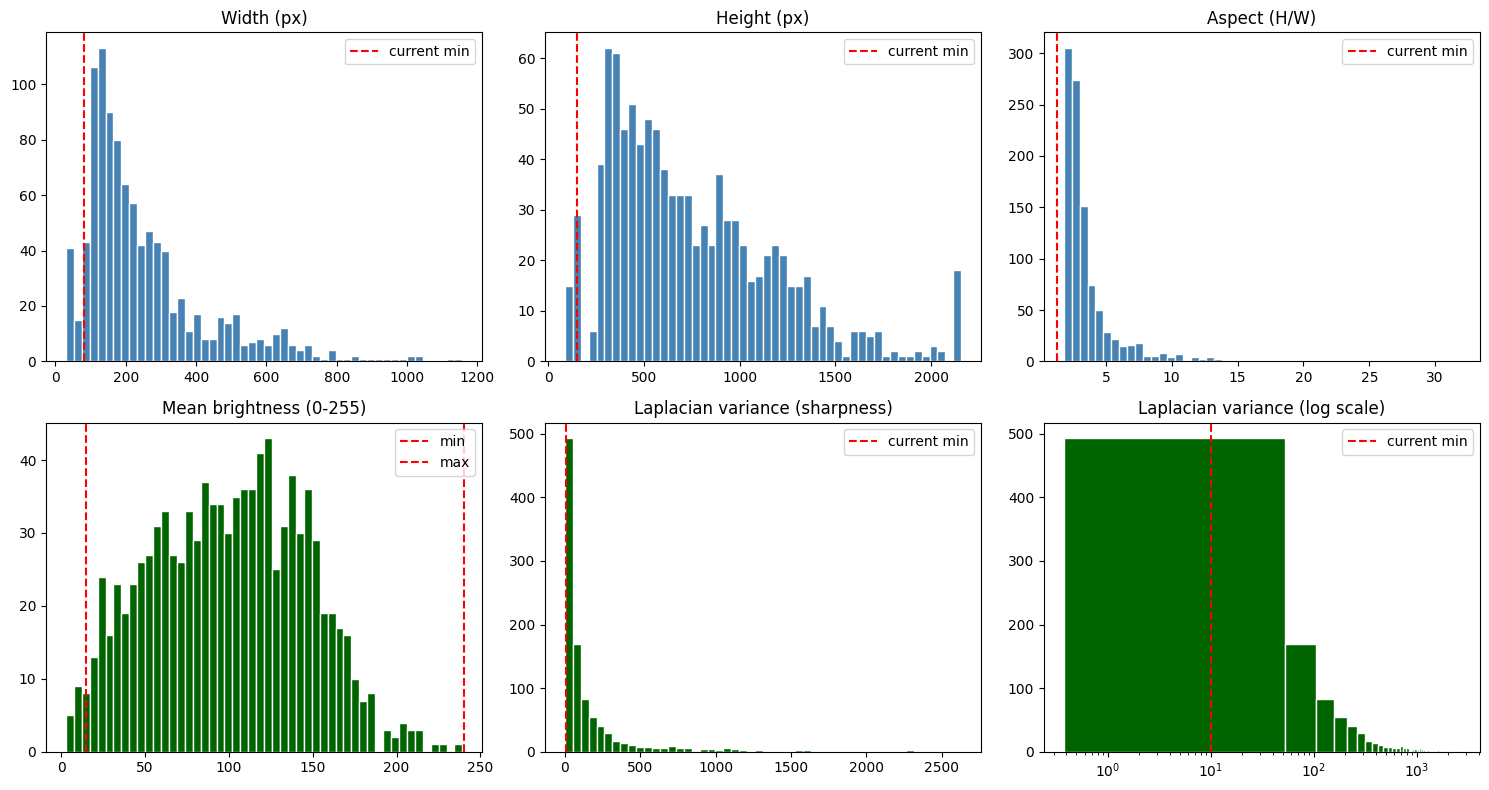

In [12]:
fig,axes = plt.subplots(2,3,figsize=(15,8))

axes[0,0].hist(df['width'],bins=50,color="steelblue",edgecolor="white")
axes[0,0].set_title("Width (px)")
axes[0,0].axvline(thresholds["quality"]["min_width"], color="red", linestyle="--", label="current min")
axes[0,0].legend()

axes[0,1].hist(df['height'],bins=50,color="steelblue",edgecolor="white")
axes[0,1].set_title("Height (px)")
axes[0,1].axvline(thresholds['quality']['min_height'],color="red",linestyle="--",label="current min")
axes[0,1].legend()

axes[0,2].hist(df['aspect'],bins=50,color="steelblue",edgecolor="white")
axes[0,2].set_title("Aspect (H/W)")
axes[0,2].axvline(thresholds['quality']['min_aspect_ratio'],color="red",linestyle="--",label="current min")
axes[0,2].legend()

axes[1,0].hist(df['brightness'],bins=50,color="darkgreen",edgecolor="white")
axes[1,0].set_title("Mean brightness (0-255)")
axes[1,0].axvline(thresholds['quality']['min_brightness'],color="red",linestyle="--",label="min")
axes[1,0].axvline(thresholds['quality']['max_brightness'],color="red",linestyle="--",label="max")
axes[1,0].legend()

axes[1,1].hist(df["blur_variance"],bins=50,color="darkgreen",edgecolor="white")
axes[1,1].set_title("Laplacian variance (sharpness)")
axes[1,1].axvline(thresholds['quality']['min_blur_variance'],color="red",linestyle="--",label="current min")
axes[1,1].legend()

# log scale variant of blur 
axes[1,2].hist(df['blur_variance'],bins=50,color="darkgreen",edgecolor="white")
axes[1,2].set_xscale("log")
axes[1,2].set_title("Laplacian variance (log scale)")
axes[1,2].axvline(thresholds["quality"]["min_blur_variance"],color="red",linestyle="--",label="current min")
axes[1,2].legend()

plt.tight_layout()
plt.show()

1. `width distribution`: Most crop images fall between roughly `100-350px` in width, while a small no of extremely narrow crops form a long tail and may require filtering.

2. `height distribution`: The dataset is dominated by tall image crops with height around `300-1300px`.

3. `aspect ratio`: The `aspect ratio` distribution, is heavily concentrated between `2-4`, with few extreme outliers caused by bad detections. This has a long tailed right skewed distribution.

4. `brightness distribution`: Brightness values form smooth unimodal distribution centered around normal exposure levels, this indicates well-lit images with only a few dark samples.

5. `blur variance (linear scale)`:  blur variance is right skewed distribution with most  images having low to moderate sharpness and a small no of extreme outliers.

6. `blur variance (log scale)`: The log scale view reveals that blur threshold lies within the main population region, this suggests the blur filter is very aggressive.

### Diplay images and their metrics

14:50:43 | INFO     | src.utils.io:load:61 | Loaded crop (707).png | shape: ((833, 2146, 3)) | bytes: 5362854
14:50:43 | INFO     | src.utils.io:load:61 | Loaded crop (198).png | shape: ((277, 885, 3)) | bytes: 735435
14:50:43 | INFO     | src.utils.io:load:61 | Loaded crop (262).png | shape: ((349, 956, 3)) | bytes: 1000932
14:50:43 | INFO     | src.utils.io:load:61 | Loaded crop (48).png | shape: ((379, 1057, 3)) | bytes: 1201809
14:50:43 | INFO     | src.utils.io:load:61 | Loaded crop (944).png | shape: ((642, 1348, 3)) | bytes: 2596248
14:50:43 | INFO     | src.utils.io:load:61 | Loaded crop (376).png | shape: ((171, 805, 3)) | bytes: 412965
14:50:43 | INFO     | src.utils.io:load:61 | Loaded crop (13).png | shape: ((338, 624, 3)) | bytes: 632736
14:50:43 | INFO     | src.utils.io:load:61 | Loaded crop (10).png | shape: ((283, 719, 3)) | bytes: 610431


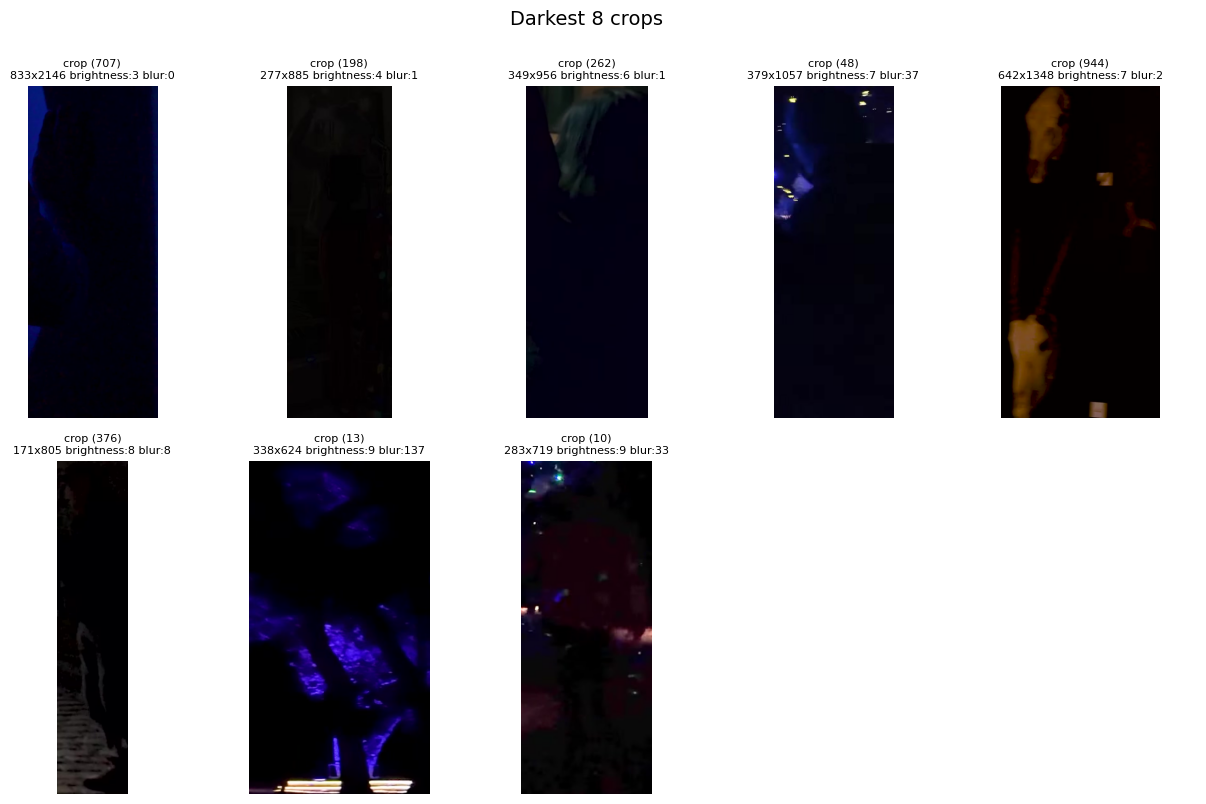

14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (468).png | shape: ((184, 337, 3)) | bytes: 186024
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (98).png | shape: ((220, 399, 3)) | bytes: 263340
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (141).png | shape: ((223, 422, 3)) | bytes: 282318
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (96).png | shape: ((172, 511, 3)) | bytes: 263676
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (853).png | shape: ((199, 1176, 3)) | bytes: 702072
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (411).png | shape: ((126, 372, 3)) | bytes: 140616
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (708).png | shape: ((650, 1187, 3)) | bytes: 2314650
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (219).png | shape: ((182, 520, 3)) | bytes: 283920


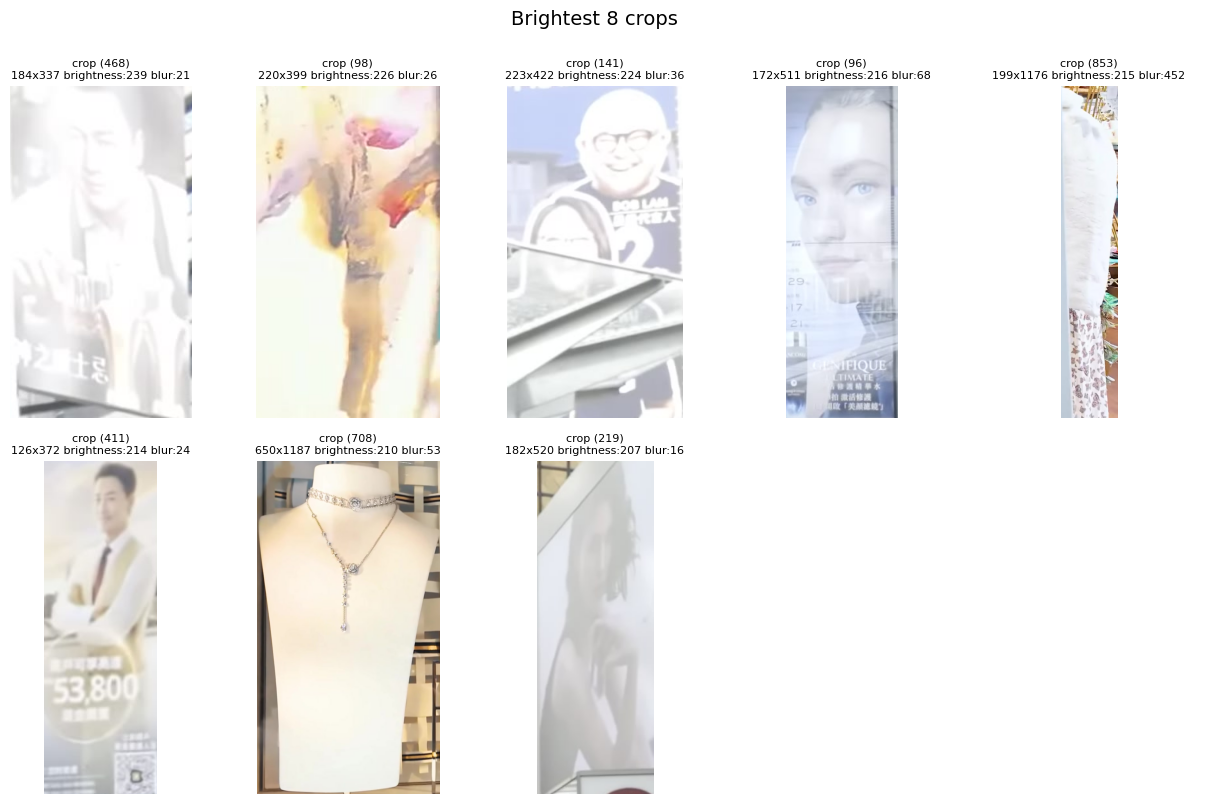

14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (707).png | shape: ((833, 2146, 3)) | bytes: 5362854
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (262).png | shape: ((349, 956, 3)) | bytes: 1000932
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (198).png | shape: ((277, 885, 3)) | bytes: 735435
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (78).png | shape: ((369, 894, 3)) | bytes: 989658
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (121).png | shape: ((311, 978, 3)) | bytes: 912474
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (1035).png | shape: ((506, 1080, 3)) | bytes: 1639440
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (14).png | shape: ((336, 1095, 3)) | bytes: 1103760
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (119).png | shape: ((313, 837, 3)) | bytes: 785943


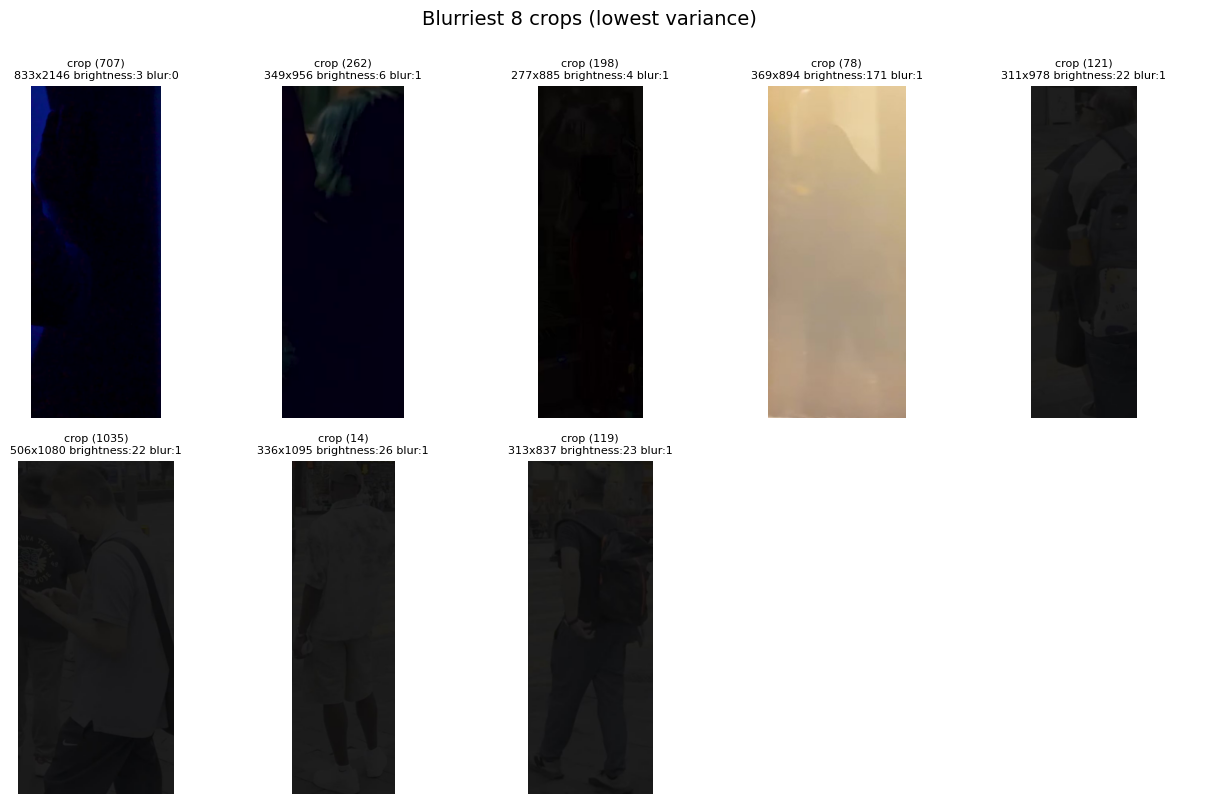

14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (68).png | shape: ((99, 473, 3)) | bytes: 140481
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (340).png | shape: ((110, 295, 3)) | bytes: 97350
14:50:44 | INFO     | src.utils.io:load:61 | Loaded crop (384).png | shape: ((95, 258, 3)) | bytes: 73530
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (394).png | shape: ((94, 283, 3)) | bytes: 79806
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (310).png | shape: ((99, 380, 3)) | bytes: 112860
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (1028).png | shape: ((173, 507, 3)) | bytes: 263133
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (93).png | shape: ((134, 384, 3)) | bytes: 154368
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (69).png | shape: ((123, 377, 3)) | bytes: 139113


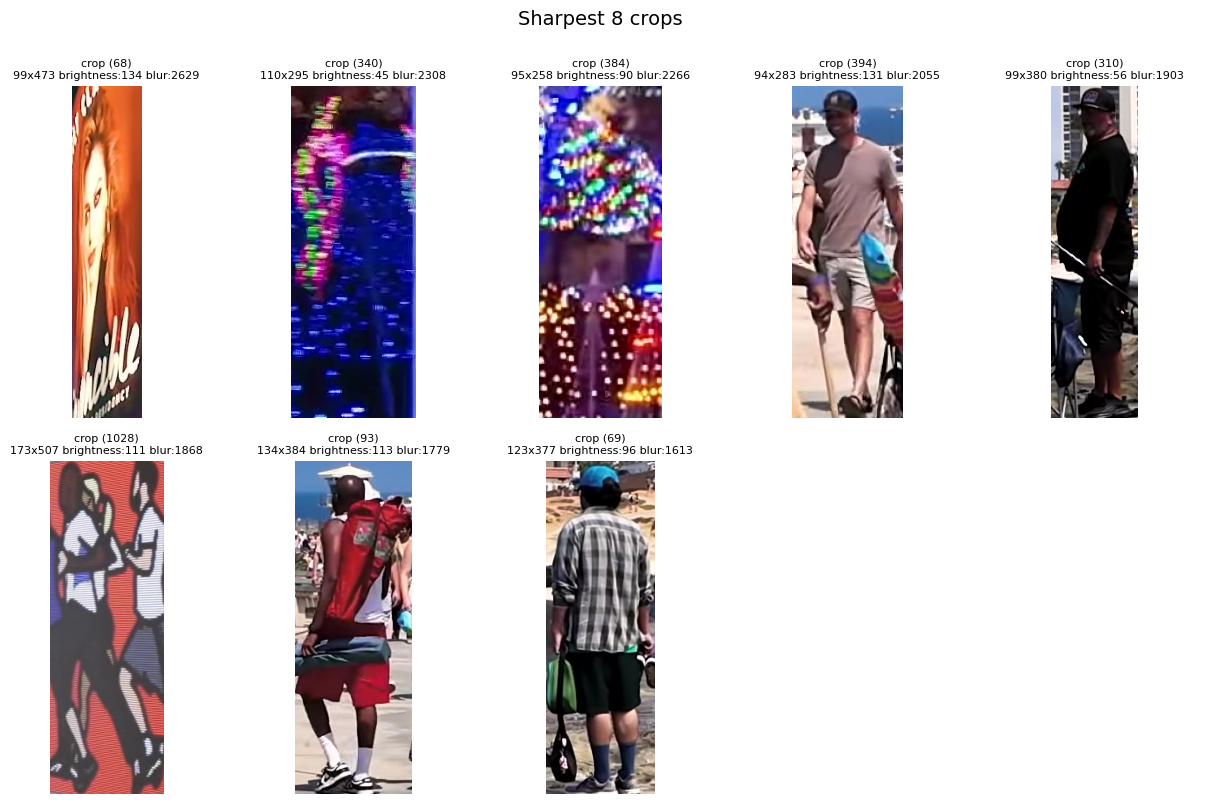

14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (541).png | shape: ((30, 86, 3)) | bytes: 7740
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (528).png | shape: ((37, 137, 3)) | bytes: 15207
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (524).png | shape: ((38, 136, 3)) | bytes: 15504
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (533).png | shape: ((38, 126, 3)) | bytes: 14364
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (534).png | shape: ((38, 118, 3)) | bytes: 13452
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (535).png | shape: ((39, 123, 3)) | bytes: 14391
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (540).png | shape: ((39, 94, 3)) | bytes: 10998
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (256).png | shape: ((40, 1276, 3)) | bytes: 153120


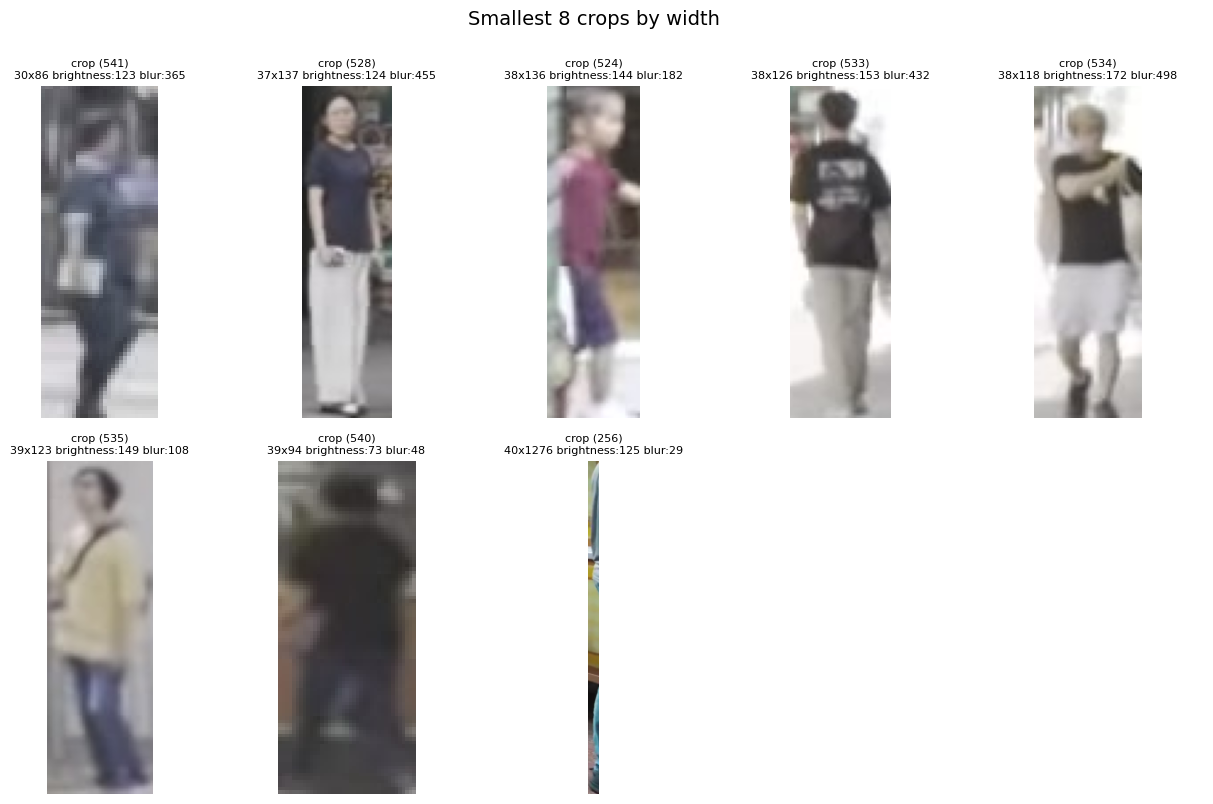

In [13]:
def show_grid(crop_df: pd.DataFrame,
              title: str,
              n_cols: int = 5) -> None:
    """Display grid of crop imgs with their metrics"""
    n = len(crop_df)
    n_rows = (n + n_cols - 1) // n_cols # how many rows are needed 
    
    fig,axes = plt.subplots(n_rows,n_cols,figsize=(n_cols*2.5,n_rows*4))
    axes = np.atleast_2d(axes).flatten() # atleast converts list into 2d np array 

    for ax,(_,row) in zip(axes,crop_df.iterrows()):
        path = next(DATA_DIR.rglob(f"{row['crop_id']}.*"))
        img = loader.load(path).image

        ax.imshow(img)
        ax.set_title(f"{row['crop_id'][:20]}\n"
                     f"{row['width']}x{row['height']} "
                     f"brightness:{row['brightness']:.0f} "
                     f"blur:{row['blur_variance']:.0f}",
                     fontsize=8)
        ax.axis('off')
    
    for ax in axes[len(crop_df):]:
        ax.axis("off")
    
    fig.suptitle(title,fontsize=14,y=1.0)
    plt.tight_layout()
    plt.show()

show_grid(df.nsmallest(8,"brightness"),"Darkest 8 crops")

show_grid(df.nlargest(8, "brightness"), "Brightest 8 crops")

show_grid(df.nsmallest(8, "blur_variance"), "Blurriest 8 crops (lowest variance)")

show_grid(df.nlargest(8, "blur_variance"), "Sharpest 8 crops")

show_grid(df.nsmallest(8, "width"), "Smallest 8 crops by width")




Crops with height > 2000: 22
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (542).png | shape: ((1130, 2158, 3)) | bytes: 7315620
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (545).png | shape: ((1030, 2158, 3)) | bytes: 6668220
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (580).png | shape: ((787, 2158, 3)) | bytes: 5095038
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (569).png | shape: ((1023, 2158, 3)) | bytes: 6622902
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (543).png | shape: ((721, 2157, 3)) | bytes: 4665591
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (562).png | shape: ((956, 2157, 3)) | bytes: 6186276
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (773).png | shape: ((147, 2156, 3)) | bytes: 950796
14:50:45 | INFO     | src.utils.io:load:61 | Loaded crop (652).png | shape: ((664, 2156, 3)) | bytes: 4294752


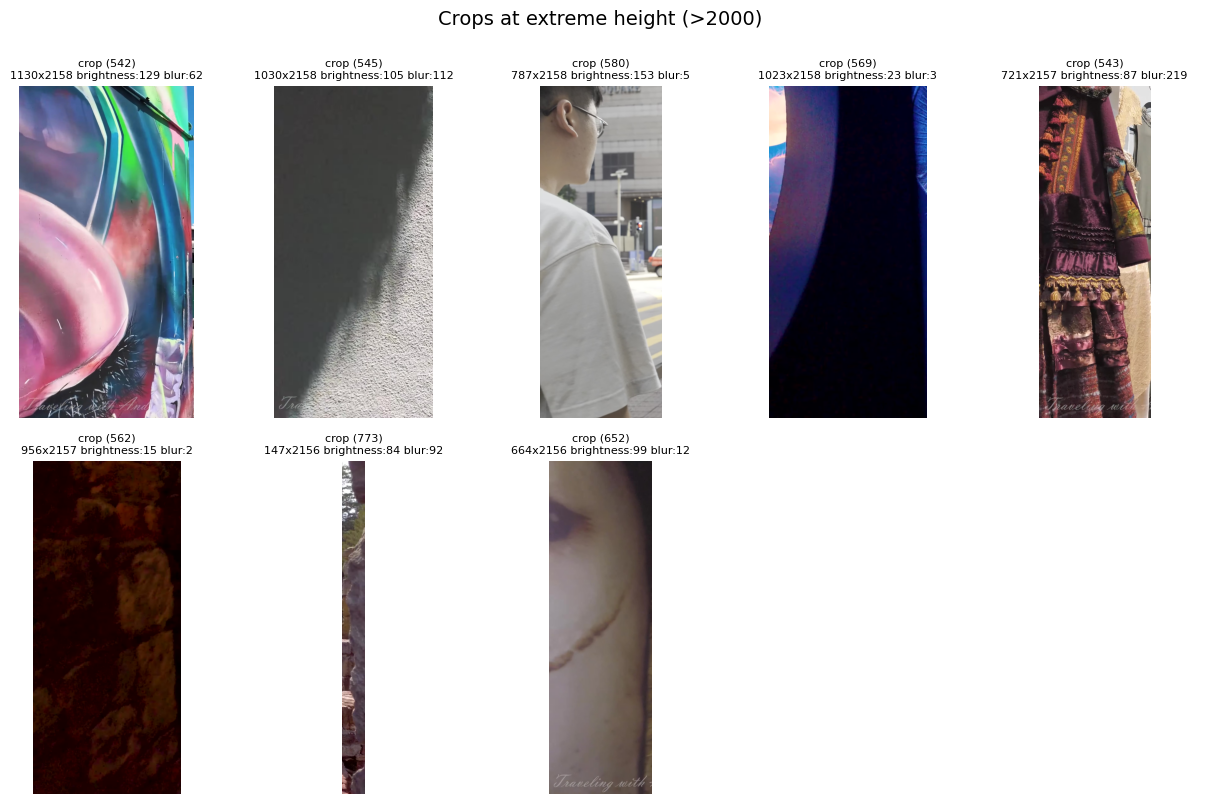

In [14]:
tall = df[df["height"] > 2000].sort_values("height", ascending=False)
print(f"Crops with height > 2000: {len(tall)}")
show_grid(tall.head(8), "Crops at extreme height (>2000)")

### Random sampling 

14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (493).png | shape: ((88, 411, 3)) | bytes: 108504
14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (943).png | shape: ((240, 1131, 3)) | bytes: 814320
14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (739)(1).png | shape: ((482, 1038, 3)) | bytes: 1500948
14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (98).png | shape: ((220, 399, 3)) | bytes: 263340
14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (379).png | shape: ((79, 839, 3)) | bytes: 198843
14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (667).png | shape: ((500, 1144, 3)) | bytes: 1716000
14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (660).png | shape: ((505, 1129, 3)) | bytes: 1710435
14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (485).png | shape: ((117, 320, 3)) | bytes: 112320
14:50:46 | INFO     | src.utils.io:load:61 | Loaded crop (775).png | shape: ((296, 866, 3)) | bytes: 769008
14:50:46 | INFO     |

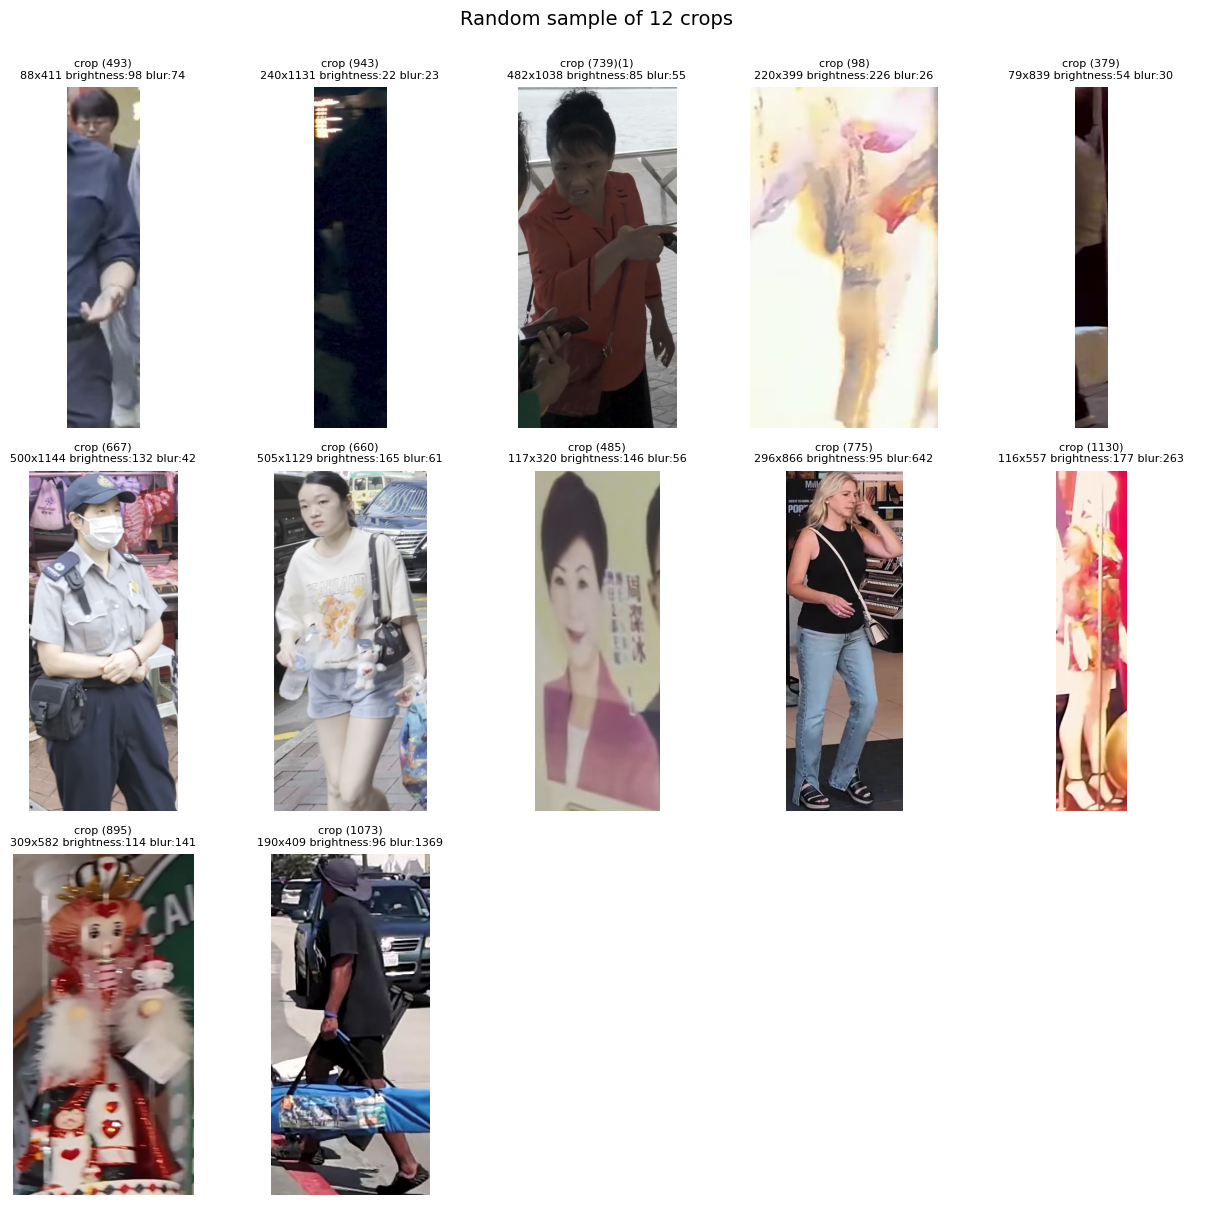

In [15]:
sample = df.sample(n=min(12, len(df)), random_state=42)
show_grid(sample, "Random sample of 12 crops")


In [16]:
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "eda"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

eda_path = ARTIFACTS_DIR / "01_eda_metrics.csv"
df.to_parquet(eda_path, index=False)
logger.info("Saved EDA metrics")

14:50:46 | INFO     | __main__:<module>:6 | Saved EDA metrics


## EDA findings - Final Summary 

# Exploratory Data Analysis (EDA)

## Dataset
- Total files in `data/raw/`: 1148, all PNG.
- 1 zero-byte file (`.gitkeep`) — a project placeholder, not a corrupt image; correctly skipped by the extension filter in `ImageLoader`.
- 0 actual corrupt image files — `ImageLoader.load()` did not reject any valid PNGs.
- 133 duplicate groups detected via MD5 content hashing → 146 redundant copies removed → **effective working set: 1001 unique crops** (~12.7% duplication rate).
- Duplicate filenames are sequential (e.g., `crop (1)/(2)`, `crop (1019)/(1020)`), suggesting the upstream crop extraction step likely wrote some files twice.

---

## Distribution Highlights (Unique Crops)

- **Width:** Most crops fall between ~100–350 px, with a small long tail of extremely narrow or oversized detections.
- **Height:** Heights are concentrated around ~300–1300 px, with a visible spike near 2150 px caused by degenerate ultra-tall crops.
- **Aspect (H/W):** Most aspect ratios cluster around 2–4 (expected for full-body people), but the max outlier of 31.9 indicates malformed ultra-thin crops.
- **Brightness:** Brightness follows a healthy unimodal distribution centered around normal exposure levels, with a few severely dark or overexposed samples.
- **Blur variance:** Blur variance is heavily right-skewed; the original threshold of 80 would remove more than half the dataset and is therefore too aggressive.

---

## Visual Sanity Check

### Blurriest-8 Crops
- Crop `(580)` appears visually sharp despite `blur=5`, confirming Laplacian variance confuses low texture with actual blur.
- Blur variance should therefore be treated only as a coarse filtering signal.

### Tallest Crops (`height > 2000`)
- The ~18-crop cluster near height ≈ 2150 is mostly invalid content:
  - walls,
  - clothing close-ups,
  - thin slivers,
  - watermarked source frames.
- These are expected to fail naturally during Stage 1 person detection.

### Random Sample of 12
- Roughly:
  - ~65–70% clean person crops,
  - ~15–20% mannequins/store displays,
  - remainder consists of low-light, blurry, or malformed crops.

### Watermarks
- Multiple crops contain visible watermark overlays (`"Traveling with..."`).
- This may influence CLIP similarity scoring during downstream filtering.

---

## Threshold Decisions

| Threshold | Old | New | Reasoning |
|---|---|---|---|
| `min_aspect_ratio` | 1.3 | 1.3 | Existing threshold already separates person-like vertical crops from wide invalid crops. |
| `min_width` | 50 | 80 | Raised to remove tiny low-detail crops that are visually unusable. |
| `min_height` | 100 | 150 | Raised to filter distant or incomplete detections with insufficient person detail. |
| `min_brightness` | 15 | 15 | Existing value already removes near-black unusable crops without affecting normal low-light images. |
| `max_brightness` | 240 | 240 | Existing value correctly targets only heavily washed-out or overexposed crops. |
| `min_blur_variance` | 80 | 10 | Dramatically lowered because visually acceptable crops can receive very low Laplacian scores due to low texture. |

---

## Implications for Downstream Stages

### Stage 1 — Person Detection
- Expected to reject:
  - malformed extreme-height crops,
  - mannequins,
  - partial detections,
  - and non-person regions.

### Stage 5 — CLIP Ad Filter
- Likely to be heavily utilized because the dataset contains:
  - mannequins,
  - posters,
  - storefront displays,
  - and watermarked promotional imagery.

### Reporting
- Final pipeline metrics should be computed on the **1001 unique crops**, not the raw 1147 files.
- Keeping duplicates would artificially inflate evaluation metrics by ~13%.